# Days Aging Prediction Model

This notebook builds a machine learning model to predict the **Days Aging** (time between bill date and payment date) for customer transactions.

## Workflow:
1. Load and explore the data
2. Clean and preprocess features
3. Split data into training and test sets
4. Train a prediction model
5. Evaluate model performance
6. Make predictions on test data

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load the dataset
df = pd.read_csv('testdatajan26_with_customers.csv')

print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 COLUMNS:")
print(df.dtypes)
print(f"\n👀 FIRST 5 ROWS:")
df.head()

📊 DATASET OVERVIEW
Shape: 7,237 rows × 6 columns

📋 COLUMNS:
Order ID           int64
Customer ID       object
Bill Date         object
Paid Date         object
Days Aging         int64
Invoice Amount    object
dtype: object

👀 FIRST 5 ROWS:


,Order ID,Customer ID,Bill Date,Paid Date,Days Aging,Invoice Amount
0,95769,CUST-157,3/3/2025,04/14/2025 1023,42,"$5,437.97"
1,95584,CUST-085,2/27/2025,04/14/2025 1023,46,"$3,364.33"
2,94371,CUST-180,2/10/2025,03/04/2025 0749,22,$743.00
3,95590,CUST-102,2/27/2025,04/14/2025 1023,46,"$3,364.33"
4,96739,CUST-065,4/16/2025,05/28/2025 0712,42,"$1,410.48"


In [3]:
# Check for missing values
print("🔍 MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print(f"\n📈 TARGET VARIABLE STATISTICS (Days Aging):")
print(df['Days Aging'].describe())

🔍 MISSING VALUES
Order ID          0
Customer ID       0
Bill Date         0
Paid Date         0
Days Aging        0
Invoice Amount    0
dtype: int64

📈 TARGET VARIABLE STATISTICS (Days Aging):
count    7237.000000
mean       27.962830
std        13.228511
min         0.000000
25%        18.000000
50%        29.000000
75%        33.000000
max       144.000000
Name: Days Aging, dtype: float64


## 3. Data Preprocessing

In [4]:
# Create a copy for preprocessing
data = df.copy()

# Clean Invoice Amount - remove $ and commas, convert to float
data['Invoice Amount'] = data['Invoice Amount'].str.replace('$', '', regex=False)
data['Invoice Amount'] = data['Invoice Amount'].str.replace(',', '', regex=False)
data['Invoice Amount'] = pd.to_numeric(data['Invoice Amount'], errors='coerce')

# Parse Bill Date
data['Bill Date'] = pd.to_datetime(data['Bill Date'], format='%m/%d/%Y', errors='coerce')

# Extract features from Bill Date
data['Bill_Month'] = data['Bill Date'].dt.month
data['Bill_DayOfWeek'] = data['Bill Date'].dt.dayofweek
data['Bill_DayOfMonth'] = data['Bill Date'].dt.day
data['Bill_Quarter'] = data['Bill Date'].dt.quarter
data['Bill_WeekOfYear'] = data['Bill Date'].dt.isocalendar().week.astype(int)

print("✅ Date features extracted")
print(f"\n📋 NEW COLUMNS: Bill_Month, Bill_DayOfWeek, Bill_DayOfMonth, Bill_Quarter, Bill_WeekOfYear")

✅ Date features extracted

📋 NEW COLUMNS: Bill_Month, Bill_DayOfWeek, Bill_DayOfMonth, Bill_Quarter, Bill_WeekOfYear


In [5]:
# Create TEMPORAL customer payment history features
# For each transaction, compute stats from PRIOR transactions only (by bill date)

# Sort by Customer and Bill Date to ensure temporal ordering
data = data.sort_values(['Customer ID', 'Bill Date']).reset_index(drop=True)

# Create expanding (cumulative) features for each customer's payment history
# These features only use data from BEFORE each observation

def compute_customer_history(group):
    """Compute rolling historical stats for each customer's transactions"""
    # Shift by 1 to exclude current row (only use prior transactions)
    group['Cust_Hist_Avg_Days'] = group['Days Aging'].shift().expanding().mean()
    group['Cust_Hist_Std_Days'] = group['Days Aging'].shift().expanding().std()
    group['Cust_Hist_Min_Days'] = group['Days Aging'].shift().expanding().min()
    group['Cust_Hist_Max_Days'] = group['Days Aging'].shift().expanding().max()
    group['Cust_Hist_Count'] = group['Days Aging'].shift().expanding().count()
    group['Cust_Hist_Avg_Invoice'] = group['Invoice Amount'].shift().expanding().mean()
    
    # Recent trend: average of last 3 payments vs overall average
    group['Cust_Hist_Recent3_Avg'] = group['Days Aging'].shift().rolling(window=3, min_periods=1).mean()
    
    # Payment consistency (coefficient of variation) - lower = more consistent
    hist_mean = group['Days Aging'].shift().expanding().mean()
    hist_std = group['Days Aging'].shift().expanding().std()
    group['Cust_Hist_Consistency'] = hist_std / (hist_mean + 1)  # +1 to avoid div by zero
    
    return group

print("🔄 Computing temporal customer payment history...")
data = data.groupby('Customer ID', group_keys=False).apply(compute_customer_history)

# Fill NaN for first transactions (no history available) with global medians
history_cols = ['Cust_Hist_Avg_Days', 'Cust_Hist_Std_Days', 'Cust_Hist_Min_Days', 
                'Cust_Hist_Max_Days', 'Cust_Hist_Count', 'Cust_Hist_Avg_Invoice',
                'Cust_Hist_Recent3_Avg', 'Cust_Hist_Consistency']

for col in history_cols:
    median_val = data[col].median()
    data[col] = data[col].fillna(median_val if pd.notna(median_val) else 0)

print("✅ Customer payment history features created!")
print(f"\n📋 NEW HISTORY FEATURES:")
for i, col in enumerate(history_cols, 1):
    print(f"  {i}. {col}")

print(f"\n📊 Sample of history features:")
data[['Customer ID', 'Bill Date', 'Days Aging'] + history_cols].head(10)

🔄 Computing temporal customer payment history...
✅ Customer payment history features created!

📋 NEW HISTORY FEATURES:
  1. Cust_Hist_Avg_Days
  2. Cust_Hist_Std_Days
  3. Cust_Hist_Min_Days
  4. Cust_Hist_Max_Days
  5. Cust_Hist_Count
  6. Cust_Hist_Avg_Invoice
  7. Cust_Hist_Recent3_Avg
  8. Cust_Hist_Consistency

📊 Sample of history features:


,Customer ID,Bill Date,Days Aging,Cust_Hist_Avg_Days,Cust_Hist_Std_Days,Cust_Hist_Min_Days,Cust_Hist_Max_Days,Cust_Hist_Count,Cust_Hist_Avg_Invoice,Cust_Hist_Recent3_Avg,Cust_Hist_Consistency
0,CUST-001,2025-01-03,28,27.542857,10.560696,9.0,47.0,0.0,2107.692500,27.666667,0.378803
1,CUST-001,2025-01-07,43,28.000000,10.560696,28.0,28.0,1.0,902.720000,28.000000,0.378803
2,CUST-001,2025-01-08,23,35.500000,10.606602,28.0,43.0,2.0,576.360000,35.500000,0.290592
3,CUST-001,2025-01-14,17,31.333333,10.408330,23.0,43.0,3.0,1584.240000,31.333333,0.321907
4,CUST-001,2025-01-15,20,27.750000,11.116804,17.0,43.0,4.0,2383.180000,27.666667,0.386671
5,CUST-001,2025-01-20,18,26.200000,10.232302,17.0,43.0,5.0,2138.134000,20.000000,0.376188
6,CUST-001,2025-01-20,18,24.833333,9.745084,17.0,43.0,6.0,1995.945000,18.333333,0.377229
7,CUST-001,2025-02-11,27,23.857143,9.263343,17.0,43.0,7.0,2339.381429,18.666667,0.372663
8,CUST-001,2025-02-13,43,24.250000,8.647873,17.0,43.0,8.0,2215.083750,21.000000,0.342490
9,CUST-001,2025-02-14,24,26.333333,10.222524,17.0,43.0,9.0,2035.996667,29.333333,0.373995


In [6]:
# Encode Customer ID
le_customer = LabelEncoder()
data['Customer_Encoded'] = le_customer.fit_transform(data['Customer ID'])

# NOTE: Customer-level features will be calculated AFTER train/test split
# to prevent data leakage (test data shouldn't influence training features)

print("✅ Customer IDs encoded")
print(f"Unique customers: {data['Customer ID'].nunique()}")
print("\n⚠️ Customer stats will be computed from training data only (to prevent leakage)")

✅ Customer IDs encoded
Unique customers: 200

⚠️ Customer stats will be computed from training data only (to prevent leakage)


In [7]:
# Display the processed data
print("📊 PROCESSED DATA SAMPLE")
print("=" * 50)
data.head()

📊 PROCESSED DATA SAMPLE


,Order ID,Customer ID,Bill Date,Paid Date,Days Aging,Invoice Amount,Bill_Month,Bill_DayOfWeek,Bill_DayOfMonth,Bill_Quarter,Bill_WeekOfYear,Cust_Hist_Avg_Days,Cust_Hist_Std_Days,Cust_Hist_Min_Days,Cust_Hist_Max_Days,Cust_Hist_Count,Cust_Hist_Avg_Invoice,Cust_Hist_Recent3_Avg,Cust_Hist_Consistency,Customer_Encoded
0,94324,CUST-001,2025-01-03,01/31/2025 0722,28,902.72,1,4,3,1,1,27.542857,10.560696,9.0,47.0,0.0,2107.6925,27.666667,0.378803,0
1,94285,CUST-001,2025-01-07,02/19/2025 0717,43,250.00,1,1,7,1,2,28.000000,10.560696,28.0,28.0,1.0,902.7200,28.000000,0.378803,0
2,94302,CUST-001,2025-01-08,01/31/2025 0728,23,3600.00,1,2,8,1,2,35.500000,10.606602,28.0,43.0,2.0,576.3600,35.500000,0.290592,0
3,94323,CUST-001,2025-01-14,01/31/2025 0728,17,4780.00,1,1,14,1,3,31.333333,10.408330,23.0,43.0,3.0,1584.2400,31.333333,0.321907,0
4,94656,CUST-001,2025-01-15,02/04/2025 0805,20,1157.95,1,2,15,1,3,27.750000,11.116804,17.0,43.0,4.0,2383.1800,27.666667,0.386671,0


## 4. Feature Selection and Train/Test Split

In [8]:
# Select base features for the model (including temporal history features)
base_feature_columns = [
    'Invoice Amount',
    'Bill_Month',
    'Bill_DayOfWeek', 
    'Bill_DayOfMonth',
    'Bill_Quarter',
    'Bill_WeekOfYear',
    'Customer_Encoded',
    # Temporal customer payment history features
    'Cust_Hist_Avg_Days',
    'Cust_Hist_Std_Days',
    'Cust_Hist_Min_Days',
    'Cust_Hist_Max_Days',
    'Cust_Hist_Count',
    'Cust_Hist_Avg_Invoice',
    'Cust_Hist_Recent3_Avg',
    'Cust_Hist_Consistency'
]

# Prepare base features (X) and target (y)
X_base = data[base_feature_columns].copy()
y = data['Days Aging'].copy()

# Handle any remaining NaN values
X_base = X_base.fillna(X_base.median())

print(f"📊 FEATURE MATRIX SHAPE: {X_base.shape}")
print(f"🎯 TARGET VECTOR SHAPE: {y.shape}")
print(f"\n📋 ALL FEATURES ({len(base_feature_columns)} total):")
for i, col in enumerate(base_feature_columns, 1):
    print(f"  {i}. {col}")

📊 FEATURE MATRIX SHAPE: (7237, 15)
🎯 TARGET VECTOR SHAPE: (7237,)

📋 ALL FEATURES (15 total):
  1. Invoice Amount
  2. Bill_Month
  3. Bill_DayOfWeek
  4. Bill_DayOfMonth
  5. Bill_Quarter
  6. Bill_WeekOfYear
  7. Customer_Encoded
  8. Cust_Hist_Avg_Days
  9. Cust_Hist_Std_Days
  10. Cust_Hist_Min_Days
  11. Cust_Hist_Max_Days
  12. Cust_Hist_Count
  13. Cust_Hist_Avg_Invoice
  14. Cust_Hist_Recent3_Avg
  15. Cust_Hist_Consistency


In [9]:
# Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

# Get the indices for train/test (for later use)
train_idx = X_train.index
test_idx = X_test.index

# Feature columns list
feature_columns = list(X_train.columns)

print("📊 TRAIN/TEST SPLIT")
print("=" * 50)
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X_base)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X_base)*100:.1f}%)")

print(f"\n✅ Temporal history features are already computed per-observation")
print(f"   (No data leakage - each row only uses prior customer transactions)")

print(f"\n📋 FEATURES ({len(feature_columns)} total):")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")

print(f"\n🎯 Target Distribution:")
print(f"  Training - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"  Test     - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

📊 TRAIN/TEST SPLIT
Training set: 5,789 samples (80.0%)
Test set:     1,448 samples (20.0%)

✅ Temporal history features are already computed per-observation
   (No data leakage - each row only uses prior customer transactions)

📋 FEATURES (15 total):
  1. Invoice Amount
  2. Bill_Month
  3. Bill_DayOfWeek
  4. Bill_DayOfMonth
  5. Bill_Quarter
  6. Bill_WeekOfYear
  7. Customer_Encoded
  8. Cust_Hist_Avg_Days
  9. Cust_Hist_Std_Days
  10. Cust_Hist_Min_Days
  11. Cust_Hist_Max_Days
  12. Cust_Hist_Count
  13. Cust_Hist_Avg_Invoice
  14. Cust_Hist_Recent3_Avg
  15. Cust_Hist_Consistency

🎯 Target Distribution:
  Training - Mean: 27.94, Std: 13.28
  Test     - Mean: 28.05, Std: 13.04


## 5. Train Prediction Models

In [10]:
# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = []

print("🚀 TRAINING MODELS")
print("=" * 50)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled data for Linear Regression, original for tree-based models
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2
    })
    
    print(f"  ✅ MAE: {mae:.2f} days | RMSE: {rmse:.2f} | R²: {r2:.4f}")

# Display results comparison
results_df = pd.DataFrame(results)
print("\n" + "=" * 50)
print("📊 MODEL COMPARISON")
print("=" * 50)
results_df

🚀 TRAINING MODELS

Training Linear Regression...
  ✅ MAE: 8.64 days | RMSE: 12.63 | R²: 0.0605

Training Random Forest...
  ✅ MAE: 5.96 days | RMSE: 9.82 | R²: 0.4327

Training Gradient Boosting...
  ✅ MAE: 6.95 days | RMSE: 10.79 | R²: 0.3148

📊 MODEL COMPARISON


,Model,MAE,RMSE,R² Score
0,Linear Regression,8.641228,12.630933,0.060507
1,Random Forest,5.959123,9.815404,0.432666
2,Gradient Boosting,6.948151,10.786666,0.314832


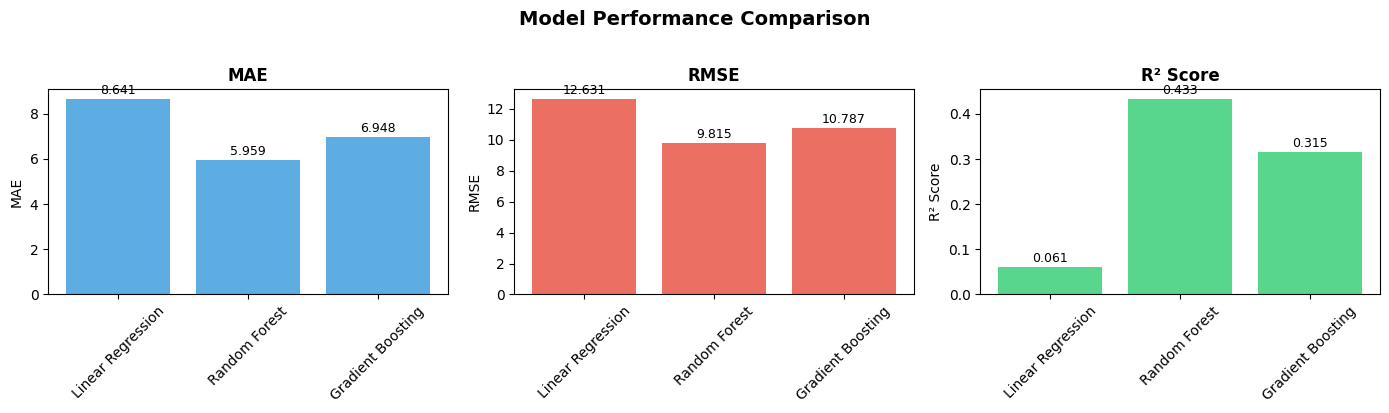

In [11]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ['MAE', 'RMSE', 'R² Score']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df['Model'], results_df[metric], color=color, alpha=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(results_df[metric]),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis

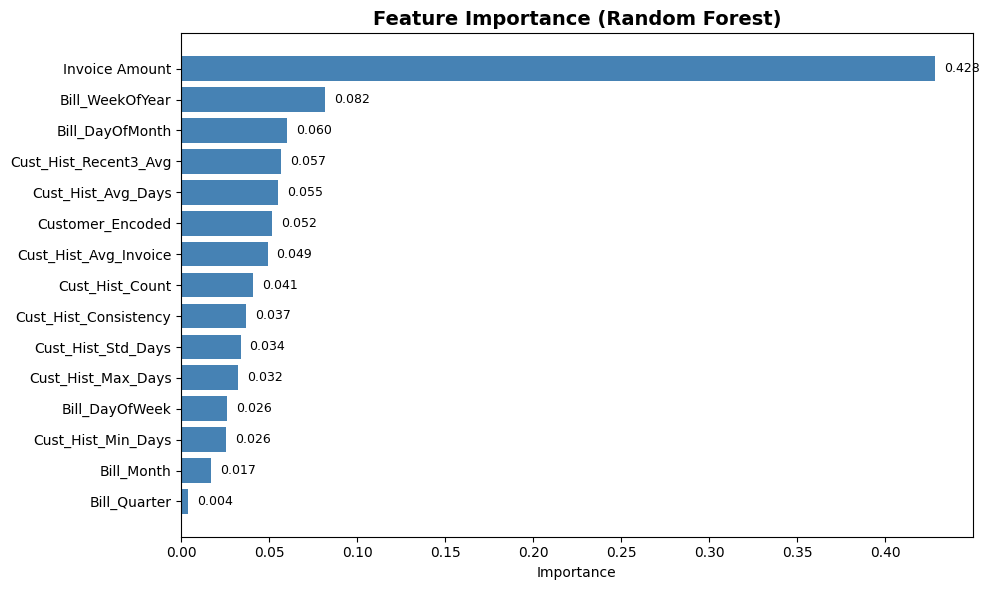


📊 FEATURE IMPORTANCE RANKING


,Feature,Importance
0,Invoice Amount,0.428153
5,Bill_WeekOfYear,0.081960
3,Bill_DayOfMonth,0.060280
13,Cust_Hist_Recent3_Avg,0.056903
7,Cust_Hist_Avg_Days,0.054994
6,Customer_Encoded,0.051691
12,Cust_Hist_Avg_Invoice,0.049133
11,Cust_Hist_Count,0.041021
14,Cust_Hist_Consistency,0.036965
8,Cust_Hist_Std_Days,0.033732


In [12]:
# Get feature importance from Random Forest (best tree-based model)
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 FEATURE IMPORTANCE RANKING")
print("=" * 50)
feature_importance

## 7. Predictions on Test Set

In [13]:
# Use the best performing model (Random Forest) for final predictions
best_model = models['Random Forest']
y_pred_final = best_model.predict(X_test)

# Create a results dataframe with actual vs predicted
test_results = pd.DataFrame({
    'Order ID': data.loc[test_idx, 'Order ID'].values,
    'Customer ID': data.loc[test_idx, 'Customer ID'].values,
    'Invoice Amount': X_test['Invoice Amount'].values,
    'Actual Days Aging': y_test.values,
    'Predicted Days Aging': np.round(y_pred_final, 1),
    'Prediction Error': np.round(y_test.values - y_pred_final, 1)
})

print("📊 TEST SET PREDICTIONS")
print("=" * 50)
print(f"Total test samples: {len(test_results):,}")
print(f"\n🎯 Prediction Summary:")
print(f"  Mean Absolute Error: {abs(test_results['Prediction Error']).mean():.2f} days")
print(f"  Within ±5 days: {(abs(test_results['Prediction Error']) <= 5).sum()} ({(abs(test_results['Prediction Error']) <= 5).mean()*100:.1f}%)")
print(f"  Within ±10 days: {(abs(test_results['Prediction Error']) <= 10).sum()} ({(abs(test_results['Prediction Error']) <= 10).mean()*100:.1f}%)")
print(f"\n👀 SAMPLE PREDICTIONS:")
test_results.head(15)

📊 TEST SET PREDICTIONS
Total test samples: 1,448

🎯 Prediction Summary:
  Mean Absolute Error: 5.96 days
  Within ±5 days: 906 (62.6%)
  Within ±10 days: 1189 (82.1%)

👀 SAMPLE PREDICTIONS:


,Order ID,Customer ID,Invoice Amount,Actual Days Aging,Predicted Days Aging,Prediction Error
0,99148,CUST-109,4445.00,8,21.0,-13.0
1,96861,CUST-025,1953.60,29,29.6,-0.6
2,94190,CUST-065,3600.00,21,25.1,-4.1
3,98472,CUST-187,568.62,29,27.4,1.6
4,101023,CUST-060,728.00,29,29.5,-0.5
5,97374,CUST-123,1557.00,25,32.0,-7.0
6,94405,CUST-150,2450.00,22,33.1,-11.1
7,98266,CUST-079,599.40,29,29.2,-0.2
8,95025,CUST-011,3728.00,23,23.2,-0.2
9,101154,CUST-164,902.76,30,17.9,12.1


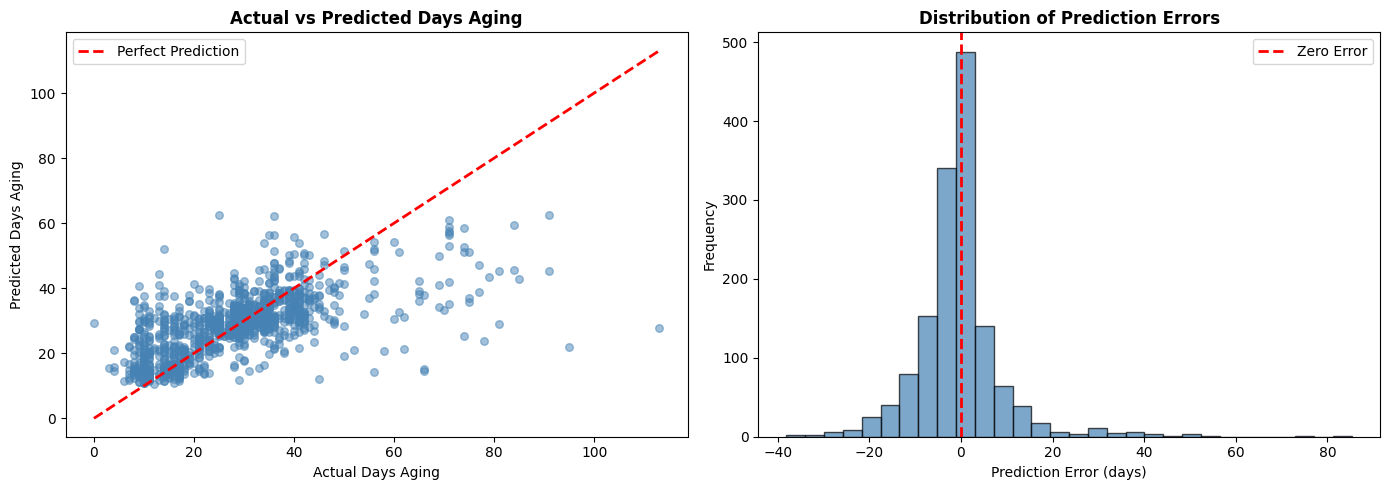

In [14]:
# Visualize Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Actual vs Predicted
ax1 = axes[0]
ax1.scatter(test_results['Actual Days Aging'], test_results['Predicted Days Aging'], 
            alpha=0.5, c='steelblue', s=30)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Days Aging')
ax1.set_ylabel('Predicted Days Aging')
ax1.set_title('Actual vs Predicted Days Aging', fontweight='bold')
ax1.legend()

# Histogram of prediction errors
ax2 = axes[1]
ax2.hist(test_results['Prediction Error'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax2.set_xlabel('Prediction Error (days)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Prediction Errors', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## 8. Export Predictions

In [15]:
# Save test predictions to CSV
test_results.to_csv('days_aging_predictions.csv', index=False)
print("✅ Test predictions saved to 'days_aging_predictions.csv'")

# Summary statistics
print("\n" + "=" * 50)
print("📊 FINAL MODEL SUMMARY")
print("=" * 50)
print(f"\nModel: Random Forest Regressor")
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples: {X_test.shape[0]:,}")
print(f"\nPerformance Metrics:")
print(f"  • Mean Absolute Error: {mean_absolute_error(y_test, y_pred_final):.2f} days")
print(f"  • Root Mean Square Error: {np.sqrt(mean_squared_error(y_test, y_pred_final)):.2f} days")
print(f"  • R² Score: {r2_score(y_test, y_pred_final):.4f}")
print(f"\n✅ Model training complete!")

✅ Test predictions saved to 'days_aging_predictions.csv'

📊 FINAL MODEL SUMMARY

Model: Random Forest Regressor
Training samples: 5,789
Test samples: 1,448

Performance Metrics:
  • Mean Absolute Error: 5.96 days
  • Root Mean Square Error: 9.82 days
  • R² Score: 0.4327

✅ Model training complete!
